In [5]:
%pip install gymnasium as gym
%pip install "gymnasium[toy-text]"
%pip install minigrid

ERROR: Could not find a version that satisfies the requirement as (from versions: none)
ERROR: No matching distribution found for as
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.7/136.7 kB 5.8 MB/s eta 0:00:00


In [6]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
env = gym.make("Taxi-v3")

print("Action space:", env.action_space)
print("Observation space:", env.observation_space)
print("Spec:", env.spec)
print("Unwrapped:", env.unwrapped)

Action space: Discrete(6)
Observation space: Discrete(500)
Spec: EnvSpec(id='Taxi-v3', entry_point='gymnasium.envs.toy_text.taxi:TaxiEnv', reward_threshold=8, nondeterministic=False, max_episode_steps=200, order_enforce=True, disable_env_checker=False, kwargs={}, namespace=None, name='Taxi', version=3, additional_wrappers=(), vector_entry_point=None)
Unwrapped: <TaxiEnv<Taxi-v3>>


In [7]:
env = gym.make("Taxi-v3")
obs, info = env.reset()

done = False
total_reward = 0
steps = 0

while not done:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)

    total_reward += reward
    steps += 1
    done = terminated or truncated

print("Steps:", steps)
print("Total reward:", total_reward)
print("Terminated:", terminated, "Truncated:", truncated)

env.close()

Steps: 200
Total reward: -731
Terminated: False Truncated: True


### Réponses - Partie A

1. Le nombre d’actions possibles est 6 : se déplacer dans les 4 directions, prendre le passager (pickup) et déposer le passager (dropoff).

2. L’observation dans Taxi-v3 est un entier représentant l’état complet du système. Cet état encode la position du taxi, la position du passager et la destination.

3. Cet environnement est adapté pour une première étude de politique car il est simple, discret et entièrement observable. Les règles sont faciles à comprendre, ce qui permet de tester facilement différentes stratégies.

In [8]:
def random_taxi_policy(obs, env):
    return env.action_space.sample()

def run_episodes(env, policy, n=20):
    results = []

    for _ in range(n):
        obs, info = env.reset()
        done = False
        total_reward = 0
        steps = 0
        success = 0

        while not done:
            action = policy(obs, env)
            obs, reward, terminated, truncated, info = env.step(action)

            total_reward += reward
            steps += 1
            done = terminated or truncated

        if reward == 20:
            success = 1

        results.append((total_reward, steps, success))

    return results

env = gym.make("Taxi-v3")
results = run_episodes(env, random_taxi_policy, 20)

rewards = [r[0] for r in results]
lengths = [r[1] for r in results]
success = [r[2] for r in results]

print("Avg reward:", np.mean(rewards))
print("Avg length:", np.mean(lengths))
print("Success rate:", np.mean(success))

Avg reward: -780.2
Avg length: 197.6
Success rate: 0.05


### Réponses - Partie B

1. Les performances restent faibles car les actions sont choisies aléatoirement sans tenir compte de l’objectif. L’agent effectue donc beaucoup d’actions inutiles et reçoit souvent des pénalités.

2. Les actions inutiles fréquentes sont :
- tenter de déposer le passager au mauvais endroit
- essayer de prendre le passager alors qu’il n’est pas présent
- déplacements sans objectif précis

In [9]:
def constrained_random_policy(obs, env):
    taxi_row, taxi_col, passenger_loc, dest = env.unwrapped.decode(obs)

    valid_actions = [0,1,2,3]  # déplacements

    # pickup possible ?
    if passenger_loc < 4 and (taxi_row, taxi_col) == env.unwrapped.locs[passenger_loc]:
        valid_actions.append(4)

    # dropoff possible ?
    if passenger_loc == 4 and (taxi_row, taxi_col) == env.unwrapped.locs[dest]:
        valid_actions.append(5)

    return np.random.choice(valid_actions)

### Réponses - Partie C

1. Le filtrage améliore les résultats car il évite certaines actions invalides, notamment les tentatives de pickup ou dropoff incorrectes, ce qui réduit les pénalités.

2. Cette politique reste limitée car elle ne guide pas réellement l’agent vers l’objectif. Elle évite seulement certaines erreurs sans optimiser le trajet.

In [10]:
env = gym.make("Taxi-v3")
obs, _ = env.reset()

print(env.unwrapped.decode(obs))

In [11]:
def heuristic_taxi_policy(obs, env):
    taxi_row, taxi_col, passenger_loc, dest = env.unwrapped.decode(obs)

    if passenger_loc < 4:
        target = env.unwrapped.locs[passenger_loc]
    else:
        target = env.unwrapped.locs[dest]

    # déplacement vers cible
    if taxi_row < target[0]:
        return 0  # south
    elif taxi_row > target[0]:
        return 1  # north
    elif taxi_col < target[1]:
        return 2  # east
    elif taxi_col > target[1]:
        return 3  # west
    else:
        if passenger_loc < 4:
            return 4  # pickup
        else:
            return 5  # dropoff

### Réponses — Partie D

1. Les éléments nécessaires sont :
- la position du taxi
- la position du passager
- la destination

2. Les cas particuliers à traiter sont :
- vérifier si le passager est déjà dans le taxi
- être exactement à la bonne position pour effectuer pickup ou dropoff

In [12]:
import pandas as pd

def evaluate_policy(env, policy, n_episodes=50):
    rewards = []
    lengths = []
    successes = []

    for _ in range(n_episodes):
        obs, info = env.reset()
        done = False
        total_reward = 0
        steps = 0
        success = 0

        while not done:
            action = policy(obs, env)
            obs, reward, terminated, truncated, info = env.step(action)

            total_reward += reward
            steps += 1
            done = terminated or truncated

        if reward == 20:
            success = 1

        rewards.append(total_reward)
        lengths.append(steps)
        successes.append(success)

    return np.mean(rewards), np.mean(lengths), np.mean(successes)


env = gym.make("Taxi-v3")

# Évaluation des 3 politiques
random_results = evaluate_policy(env, random_taxi_policy)
constrained_results = evaluate_policy(env, constrained_random_policy)
heuristic_results = evaluate_policy(env, heuristic_taxi_policy)

# Création du tableau
df = pd.DataFrame({
    "Politique": ["Aléatoire", "Contrainte", "Heuristique"],
    "Reward moyen": [
        random_results[0],
        constrained_results[0],
        heuristic_results[0]
    ],
    "Longueur moyenne": [
        random_results[1],
        constrained_results[1],
        heuristic_results[1]
    ],
    "Taux de succès": [
        random_results[2],
        constrained_results[2],
        heuristic_results[2]
    ]
})

print(df)

     Politique  Reward moyen  Longueur moyenne  Taux de succès
0    Aléatoire       -771.76            195.40            0.06
1   Contrainte       -190.00            193.36            0.16
2  Heuristique       -178.78            180.88            0.10


In [13]:
import minigrid
env = gym.make("MiniGrid-Empty-16x16-v0")

print(env.action_space)
print(env.observation_space)
print(env.spec)

Discrete(7)
Dict('direction': Discrete(4), 'image': Box(0, 255, (7, 7, 3), uint8), 'mission': MissionSpace(<function EmptyEnv._gen_mission at 0x7960afd16700>, None))
EnvSpec(id='MiniGrid-Empty-16x16-v0', entry_point='minigrid.envs:EmptyEnv', reward_threshold=None, nondeterministic=False, max_episode_steps=None, order_enforce=True, disable_env_checker=False, kwargs={'size': 16}, namespace=None, name='MiniGrid-Empty-16x16', version=0, additional_wrappers=(), vector_entry_point=None)


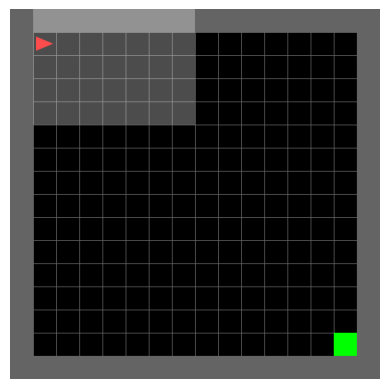

In [14]:
env = gym.make("MiniGrid-Empty-16x16-v0", render_mode="rgb_array")
obs, _ = env.reset()

plt.imshow(env.render())
plt.axis("off")
plt.show()

### Réponses - Partie E

1. MiniGrid est plus difficile à lire car l’observation n’est pas un état simple mais une représentation partielle sous forme d’image.

2. L’observation devient partielle et l’agent ne voit qu’une partie de l’environnement. L’exploration devient plus difficile car l’agent ne connaît pas directement la position de l’objectif.

In [15]:
def random_minigrid_policy(obs, info, env, step):
    return env.action_space.sample()

In [16]:
def reflex_policy(obs, info, env, step):
    return np.random.choice([0,1,2])  # tourner + avancer

In [17]:
class MemoryPolicy:
    def __init__(self):
        self.visited = set()

    def __call__(self, obs, info, env, step):
        pos = tuple(obs["image"].flatten())

        if pos in self.visited:
            return env.action_space.sample()
        else:
            self.visited.add(pos)
            return 2  # forward

In [18]:
from gymnasium.wrappers import RecordEpisodeStatistics

env = gym.make("Taxi-v3")
env = RecordEpisodeStatistics(env)

obs, _ = env.reset()

done = False
while not done:
    obs, reward, terminated, truncated, info = env.step(env.action_space.sample())
    done = terminated or truncated

print(info["episode"])

{'r': -740.0, 'l': 200, 't': 0.014715}


In [20]:
def evaluate_minigrid_policy(env, policy, n_episodes=20):
    rewards = []
    lengths = []
    successes = []

    for _ in range(n_episodes):
        obs, info = env.reset()
        done = False
        total_reward = 0
        steps = 0
        success = 0

        while not done:
            action = policy(obs, info, env, steps)
            obs, reward, terminated, truncated, info = env.step(action)

            total_reward += reward
            steps += 1
            done = terminated or truncated

        # En MiniGrid : succès si reward > 0
        if total_reward > 0:
            success = 1

        rewards.append(total_reward)
        lengths.append(steps)
        successes.append(success)

    return np.mean(rewards), np.mean(lengths), np.mean(successes)

In [21]:
def minigrid_random_policy(obs, info, env, step):
    return env.action_space.sample()


def minigrid_reflex_policy(obs, info, env, step):
    return np.random.choice([0, 1, 2])  # left, right, forward


class MiniGridMemoryPolicy:
    def __init__(self):
        self.visited = set()

    def __call__(self, obs, info, env, step):
        key = tuple(obs["image"].flatten())

        if key in self.visited:
            return env.action_space.sample()
        else:
            self.visited.add(key)
            return 2  # forward

In [22]:
env_mini = gym.make("MiniGrid-Empty-16x16-v0")

minigrid_random_results = evaluate_minigrid_policy(env_mini, minigrid_random_policy)
minigrid_reflex_results = evaluate_minigrid_policy(env_mini, minigrid_reflex_policy)
minigrid_memory_results = evaluate_minigrid_policy(env_mini, MiniGridMemoryPolicy())

In [23]:
import pandas as pd

data = [
    ["Taxi-v3", "Aléatoire", *random_results],
    ["Taxi-v3", "Contrainte", *constrained_results],
    ["Taxi-v3", "Heuristique", *heuristic_results],
    ["MiniGrid", "Aléatoire", *minigrid_random_results],
    ["MiniGrid", "Réflexe", *minigrid_reflex_results],
    ["MiniGrid", "Mémoire minimale", *minigrid_memory_results],
]

df_final = pd.DataFrame(data, columns=[
    "Environnement", "Politique",
    "Reward moyen", "Longueur moyenne", "Taux de succès"
])

print(df_final)

  Environnement         Politique  Reward moyen  Longueur moyenne  \
0       Taxi-v3         Aléatoire   -771.760000            195.40   
1       Taxi-v3        Contrainte   -190.000000            193.36   
2       Taxi-v3       Heuristique   -178.780000            180.88   
3      MiniGrid         Aléatoire      0.026392           1005.35   
4      MiniGrid           Réflexe      0.107441            930.20   
5      MiniGrid  Mémoire minimale      0.155103            887.35   

   Taux de succès  
0            0.06  
1            0.16  
2            0.10  
3            0.10  
4            0.25  
5            0.35  


### Réponses - Partie F

1. L’aléatoire est inefficace dans une grille 16×16 car l’espace est grand et l’agent explore sans stratégie, ce qui rend très improbable l’atteinte de l’objectif.

2. La rareté de la récompense rend l’apprentissage difficile car l’agent reçoit peu de feedback positif, ce qui ralentit la découverte d’une bonne stratégie.

### Réponses - Partie G

1. Une politique réflexe peut tourner en rond car elle ne prend en compte que des informations locales et ne se souvient pas des positions déjà visitées.

2. Il manque une mémoire et une vision globale de l’environnement pour prendre de meilleures décisions.

### Réponses - Partie H

1. L’ajout d’une mémoire permet à l’agent d’éviter de revisiter les mêmes états, ce qui améliore l’exploration.

2. On observe une amélioration du taux de succès et une réduction du nombre d’étapes inutiles.

### Réponse - Partie I

Taxi-v3 est plus simple car l’état est entièrement observable et discret. MiniGrid est plus complexe car l’agent a une vision partielle et doit explorer un espace plus grand. La conception d’une politique est donc plus facile dans Taxi-v3.

## Réponses de synthèse

1. Une politique est une fonction qui associe à chaque état une action à effectuer.

2. Taxi-v3 permet de construire facilement une politique car toutes les informations sont directement accessibles.

3. MiniGrid rend l’exploration difficile à cause de l’observation partielle et de la taille de l’environnement.

4. Les politiques codées à la main sont limitées car elles ne sont pas adaptatives et ne généralisent pas.

In [28]:
def capture_episode_frames(env_id, policy_fn, seed=0, max_steps=200):
    import gymnasium as gym

    env = gym.make(env_id, render_mode="rgb_array")

    frames = []

    obs, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        frame = env.render()
        frames.append(frame)

        action = policy_fn(obs, info, env, steps)
        obs, reward, terminated, truncated, info = env.step(action)
        steps += 1

    env.close()
    return frames

In [29]:
import matplotlib.pyplot as plt

def show_selected_frames(frames):
    if len(frames) == 0:
        print("Aucune frame capturée.")
        return

    indices = [0, len(frames)//2, len(frames)-1]

    for idx in indices:
        plt.figure(figsize=(4, 4))
        plt.imshow(frames[idx])
        plt.axis("off")
        plt.title(f"Frame {idx}")
        plt.show()

In [31]:
def taxi_policy_wrapper(obs, info, env, step):
    return random_taxi_policy(obs, env)

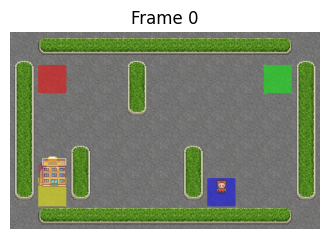

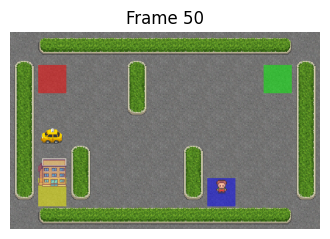

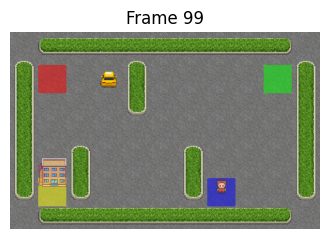

In [32]:
frames_taxi_random = capture_episode_frames(
    "Taxi-v3",
    taxi_policy_wrapper,
    seed=0,
    max_steps=100
)

show_selected_frames(frames_taxi_random)

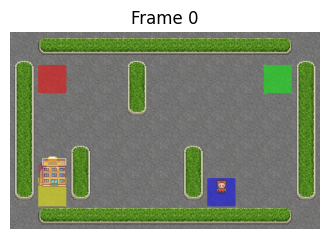

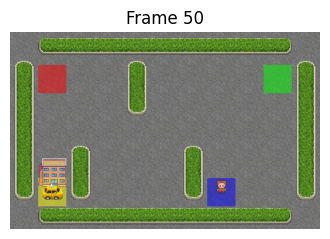

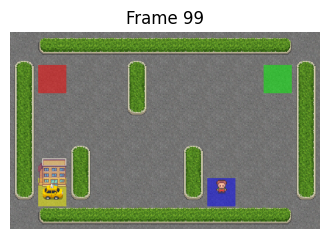

In [34]:
def taxi_policy_wrapper(obs, info, env, step):
    return heuristic_taxi_policy(obs, env)

frames_taxi_heuristic = capture_episode_frames(
    "Taxi-v3",
    taxi_policy_wrapper,
    seed=0,
    max_steps=100
)

show_selected_frames(frames_taxi_heuristic)

In [38]:
from gymnasium.wrappers import RecordVideo
from pathlib import Path
import gymnasium as gym

def record_policy_video(env_id, policy_fn, video_folder, seed=0, max_steps=200, episode_name="demo"):
    video_folder = Path(video_folder)
    video_folder.mkdir(parents=True, exist_ok=True)

    env = gym.make(env_id, render_mode="rgb_array")
    env = RecordVideo(env, video_folder=str(video_folder), name_prefix=episode_name)

    obs, info = env.reset(seed=seed)
    terminated = False
    truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        action = policy_fn(obs, info, env, steps)
        obs, reward, terminated, truncated, info = env.step(action)
        steps += 1

    env.close()
    return video_folder

In [45]:
# Instancier la politique mémoire
minigrid_memory_policy = MiniGridMemoryPolicy()

# ---- Taxi ----
def taxi_random_wrapper(obs, info, env, step):
    return random_taxi_policy(obs, env)

def taxi_heuristic_wrapper(obs, info, env, step):
    return heuristic_taxi_policy(obs, env)

record_policy_video("Taxi-v3", taxi_random_wrapper, "videos_taxi", episode_name="random")
record_policy_video("Taxi-v3", taxi_heuristic_wrapper, "videos_taxi", episode_name="heuristic")

# ---- MiniGrid ----
record_policy_video("MiniGrid-Empty-16x16-v0", minigrid_random_policy, "videos_minigrid", episode_name="random")
record_policy_video("MiniGrid-Empty-16x16-v0", minigrid_memory_policy, "videos_minigrid", episode_name="memory")

PosixPath('videos_minigrid')

## Analyse visuelle

1. Avec la politique aléatoire, l'agent tourne en rond et tente des
pickup/dropoff au mauvais endroit. Avec la politique réflexe,
des blocages apparaissent dans les coins. La politique avec mémoire
réduit ces répétitions mais hésite parfois.

2. La politique heuristique sur Taxi-v3 et la politique avec mémoire
sur MiniGrid, car elles produisent des trajectoires plus directes
et atteignent l'objectif plus rapidement.

3. Oui. Les politiques avec un faible reward produisent des trajectoires
longues et désorganisées, tandis que les meilleures politiques montrent
des trajectoires courtes et efficaces, ce qui confirme les métriques.oire plus directe.